<font size=6>实验1：PyTorch基本操作及前馈神经网络</font>

# 实验简介

本实验介绍PyTorch及其他常用Python工具包的使用方法。通过本实验，你将掌握以下技能：

- PyTorch的基本数据操作
- 数据预处理方法
- PyTorch自动微分
- 搭建并训练全连接神经网络

# 安装PyTorch

首先，你需要安装完成本实验所需的工具包。为了加快安装速度，请确保`pip`包管理器已切换到国内源。

In [1]:
from importlib.util import find_spec

# 检查PyTorch是否已安装
if find_spec('torch').loader:
    print('PyTorch is available.')
else:
    !pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple/  # 安装PyTorch最新的CPU稳定版本
    
# 检查torchvision是否已安装
if find_spec('torchvision').loader:
    print('torchvision is available.')
else:
    !pip install torchvision -i https://pypi.tuna.tsinghua.edu.cn/simple/  # 安装torchvision

PyTorch is available.
torchvision is available.


如果你希望安装GPU版本，请参阅[[Link]](https://pytorch.org/get-started/locally/)。

# PyTorch数据操作

首先，我们导入`torch`。请注意，虽然框架名称为`PyTorch`，但我们应该导入`torch`而不是`pytorch`。

In [3]:
# 防止可能的kmp_duplicate_lib_ok错误
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [4]:
import torch

PyTorch的基本计算单元是张量（Tensor）。张量表示由一个数值组成的数组，这个数组可能有多个维度。

定义张量的方法很多，我们这里定义一个从0开始，间隔为1，长度为12的等差数列张量。

In [5]:
x = torch.arange(12)

In [4]:
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

## 查看张量形状和元素数量

可以通过张量的`shape`属性来访问张量的形状和张量中元素的总数。

In [6]:
x.shape  # 查看张量x的形状

torch.Size([12])

In [7]:
x.numel()  # 查看张量x中元素的个数（Number of elements）

12

使用`len`函数返回的是张量最外层的维度。

In [8]:
len(x)

12

## 改变张量形状

要改变一个张量的形状而不改变元素数量和元素值，可以调用`reshape`函数。

In [9]:
X = x.reshape(3, 4)

In [10]:
X

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

## 常见的张量构造方法

我们经常需要使用全0、全1、其他常量或者从特定分布中随机采样的数字构建张量，构建方法如下。

In [11]:
torch.zeros((2, 3, 4))

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [12]:
torch.ones((2, 3, 4))

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

In [13]:
torch.randn(3, 4)  # 表示构建一个形状为3×4，每个元素随机采样，且采样得到的随机数服从标准正态分布的张量

tensor([[-0.3492,  1.1914,  0.4407,  0.7796],
        [-1.2584,  0.8739,  1.1204,  0.4112],
        [ 0.6011,  0.1034, -1.4944, -0.9101]])

In [14]:
torch.rand(3, 4)  # 表示构建一个形状为3×4，每个元素随机采样，且采样得到的随机数服从均匀分布、元素范围从0到1的张量

tensor([[0.5584, 0.6472, 0.3137, 0.1798],
        [0.6172, 0.6900, 0.0556, 0.2600],
        [0.9291, 0.1385, 0.3868, 0.8826]])

通过提供包含数值的Python列表（或嵌套列表）来为所需张量中的每个元素赋予确定值。

In [15]:
torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])  # 也就是手工构造一个张量

tensor([[2, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])

## 按元素计算

对张量使用常见的标准算术运算符（加、减、乘、除、幂运算等），可实现按元素运算。

In [16]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])
x + y, x - y, x * y, x / y, x**y

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

In [17]:
torch.exp(x)

tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

两个矩阵的按元素乘法称为哈达玛积（Hadamard product）（数学符号⊙）。

In [18]:
A = torch.arange(9).reshape(3, 3)
B = torch.randn(3, 3)
A, B

(tensor([[0, 1, 2],
         [3, 4, 5],
         [6, 7, 8]]),
 tensor([[ 0.5642, -0.5874, -0.1456],
         [-0.0193, -1.5569, -0.9603],
         [ 1.5182,  0.8635,  0.5818]]))

In [19]:
A * B

tensor([[ 0.0000, -0.5874, -0.2913],
        [-0.0580, -6.2277, -4.8017],
        [ 9.1090,  6.0445,  4.6542]])

## 张量的连结

我们也可以通过`torch.cat`方法把多个张量连结（concatenate）在一起，且通过`dim`参数可指定在哪个维度进行连结。

In [20]:
X = torch.arange(12, dtype=torch.float32).reshape((3, 4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
X, Y

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]),
 tensor([[2., 1., 4., 3.],
         [1., 2., 3., 4.],
         [4., 3., 2., 1.]]))

In [21]:
torch.cat((X, Y), dim=0)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [ 2.,  1.,  4.,  3.],
        [ 1.,  2.,  3.,  4.],
        [ 4.,  3.,  2.,  1.]])

In [22]:
torch.cat((X, Y), dim=1)

tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
        [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
        [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]])

## 张量逻辑运算

通过张量之间的逻辑运算，可构建二元张量。

In [23]:
X == Y

tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

## 张量元素求和

对张量中的所有元素进行求和会产生一个只有一个元素的张量。

In [24]:
X.sum()

tensor(66.)

当然，我们也可以沿某根轴进行求和。

In [25]:
X.sum(axis=0)

tensor([12., 15., 18., 21.])

In [26]:
X.sum(axis=1)

tensor([ 6., 22., 38.])

In [27]:
X.sum(axis=[0, 1])

tensor(66.)

一个与求和相关的量是平均值（mean或average）。

In [28]:
X.mean()

tensor(5.5000)

In [29]:
X.mean(axis=0)

tensor([4., 5., 6., 7.])

指定`keepdims=True`，能够在计算总和或均值时保持轴数不变。

In [30]:
X.sum(axis=1, keepdims=True)

tensor([[ 6.],
        [22.],
        [38.]])

沿某个轴计算元素的累积总和。

In [31]:
X.cumsum(axis=0)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  6.,  8., 10.],
        [12., 15., 18., 21.]])

## 广播机制

即使张量形状不同，我们仍然可以通过调用广播机制（broadcasting mechanism）来执行按元素操作。

In [32]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

In [33]:
a + b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

> 思考：请你通过多次尝试，总结广播机制的计算规则。

## 点积和矩阵乘法

点积是相同位置的按元素乘积的和。

In [34]:
x = torch.arange(4, dtype=torch.float32)
y = torch.ones(4, dtype=torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

`torch.mm`可实现矩阵乘法。

In [35]:
A = torch.randn(3, 4)
B = torch.ones(4, 3)
A, B

(tensor([[ 0.1290, -0.1713, -0.4721,  0.7748],
         [ 1.2656, -0.2927,  0.9996,  1.3804],
         [ 2.0706, -0.2655, -0.4577, -0.8703]]),
 tensor([[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]))

In [36]:
torch.mm(A, B)

tensor([[0.2604, 0.2604, 0.2604],
        [3.3530, 3.3530, 3.3530],
        [0.4771, 0.4771, 0.4771]])

## 切片

张量可以方便地进行切片操作，即取出张量的某个部分。

注意，PyTorch的索引规则与Python保持一致，索引从0开始。

例如，可以用`[-1]`选择最后一个元素，可以用`[1:3]`选择第二个和第三个元素。

In [37]:
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [38]:
X[-1], X[1:3]

(tensor([ 8.,  9., 10., 11.]),
 tensor([[ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

In [39]:
X[0, 1]

tensor(1.)

In [40]:
X[0, 1:3]

tensor([1., 2.])

In [41]:
X[:2, 1:3]

tensor([[1., 2.],
        [5., 6.]])

In [42]:
X[:, 1:3]

tensor([[ 1.,  2.],
        [ 5.,  6.],
        [ 9., 10.]])

除读取外，我们还可以通过指定索引来将元素写入张量。

In [43]:
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [44]:
X[1, 2] = 9
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  9.,  7.],
        [ 8.,  9., 10., 11.]])

为多个元素赋值相同的值，我们只需要索引所有元素，然后为它们赋值。

In [45]:
X[0:2, :] = 12
X

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

## 原地操作（In-place operation）

运行一些操作可能会导致为新结果分配内存。

In [46]:
before = id(Y)  # id函数返回对象的唯一ID，或者说（虚拟）内存地址
Y = Y + X
id(Y) == before

False

执行原地操作则能够避免为结果重新分配内存。

In [47]:
Z = torch.zeros_like(Y)
print('id(Z):', id(Z))
Z[:] = X + Y  # 切片操作能够避免重新分配内存
print('id(Z):', id(Z))

id(Z): 1709210998400
id(Z): 1709210998400


如果在后续计算中没有重复使用`X`，我们也可以使用`X[:] = X + Y`或`X += Y`来减少操作的内存开销。

In [48]:
before = id(X)
X += Y
id(X) == before

True

使用`clone`函数能够开辟新的内存空间，并得到一个数值上完全相同的张量。

In [49]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
B = A.clone()
A, B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]))

In [50]:
id(A) == id(B)

False

## 与NumPy数组或Python标量的相互转换

与 NumPy 数组的转换。

In [51]:
A = X.numpy()
B = torch.tensor(A)
type(A), type(B)

(numpy.ndarray, torch.Tensor)

将大小为1的张量转换为 Python 标量。

In [52]:
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

# 数据预处理

首先，我们创建一个人工数据集，并存储在csv（逗号分隔值）文件。

In [53]:
import os

os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n')
    f.write('NA,Pave,127500\n')
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

从创建的csv文件中加载原始数据集。

In [54]:
import pandas as pd

data = pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


## 处理缺失值

为了处理缺失的数据，典型的方法包括插值和删除，这里，我们将考虑插值。

In [55]:
inputs, outputs = data.iloc[:, 0:2], data.iloc[:, 2]

In [56]:
inputs

,NumRooms,Alley
0,NaN,Pave
1,2.0,NaN
2,4.0,NaN
3,NaN,NaN


In [57]:
inputs = inputs.fillna(inputs.mean(numeric_only=True))
inputs

,NumRooms,Alley
0,3.0,Pave
1,2.0,NaN
2,4.0,NaN
3,3.0,NaN


## 类别值转换为数值

对于inputs中的类别值或离散值，我们将“NaN”视为一个类别。

In [58]:
inputs = pd.get_dummies(inputs, dummy_na=True)
inputs

,NumRooms,Alley_Pave,Alley_nan
0,3.0,1,0
1,2.0,0,1
2,4.0,0,1
3,3.0,0,1


现在`inputs`和`outputs`中的所有条目都是数值类型，它们可以转换为张量格式

In [59]:
X, y = torch.tensor(inputs.values), torch.tensor(outputs.values)
X, y

(tensor([[3., 1., 0.],
         [2., 0., 1.],
         [4., 0., 1.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500, 106000, 178100, 140000]))

# 自动微分

假设我们想对函数$y = 2 \mathbf{x}^{\mathrm{T}} \mathbf{x}$ 关于列向量$\mathbf{x}$求导。

In [60]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

首先，我们要为`x`开启存储梯度的功能。

In [61]:
x.requires_grad_(True)
print(x.grad)

None


现在让我们计算$y$。

In [62]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

通过调用反向传播函数来自动计算`y`关于`x`每个分量的梯度。

In [63]:
y.backward()
print(x.grad)

tensor([ 0.,  4.,  8., 12.])


In [64]:
x.grad == 4 * x

tensor([True, True, True, True])

现在让我们计算`x`的另一个函数。

In [65]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()  # 方法后以'_'结尾代表原地修改值
y = x.sum()
y.backward()
print(x.grad)

tensor([1., 1., 1., 1.])


在PyTorch中有个简单的规定，不允许向量对向量求导，只允许标量对向量求导。因此，一个向量调用`backward()`，则需要传入一个`gradient`参数。传入这个参数就是为了把向量对向量的求导转换为标量对向量的求导。

In [66]:
x.grad.zero_()
y = x * x  # 向量元素相乘，得到的仍是向量，此时存在向量对向量求导的情况
y.sum().backward()  # 等价于y.backward(torch.ones(len(x))) ；这里我们首先将向量y降维成标量
print(x.grad)

tensor([0., 2., 4., 6.])


将某些计算移动到记录的计算图之外。

In [67]:
x.grad.zero_()
y = x * x
u = y.detach()  # 把y的值赋给u，u不进入计算图，作为常数处理
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [68]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

即使构建函数的计算图需要通过Python控制流（例如，条件、循环或任意函数调用），我们仍然可以计算得到的变量的梯度。

In [69]:
def f(a):
    b = a * 2
    while b.norm() < 1000:  # b.norm：求L2范数
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

a.grad == d / a

tensor(True)

# 搭建全连接神经网络

在本节中，我们将搭建一个全连接神经网络，用于解决图像的分类问题。

## 数据集下载

本实验将使用[Fasion-MNIST](https://github.com/zalandoresearch/fashion-mnist)数据集。该数据集是一个旨在替代原始的MNIST手写数字数据集的简易图像分类数据集，由Zalando（一家德国的时尚科技公司）旗下的研究部门提供，包含10个类别、共7万张不同商品的正面图片。Fashion-MNIST的大小、格式和训练集/测试集划分与原始的MNIST完全一致，即包含60000张训练图片，10000张测试图片，每张图片均为28x28的灰度图。

首先，导入必要的包。

In [70]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch import nn, optim
import torch.nn.functional as F 
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

定义一个图像预处理器，用于将图像数据标准化，使得每个像素的灰度值从0到1转换为-1到+1之间。

In [71]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

接下来，下载数据并定义训练和测试集数据加载器（DataLoader）。数据集下载约需几分钟时间。

如果下载速度太慢，可通过以下链接手动下载[[Link]](https://pan.baidu.com/s/1rrobbxAzhJyBnAYRYvKL1w)（提取码：dju3），并将`train-images-idx3-ubyte.gz`等4个文件放在`dataset/FashionMNIST/raw`目录下，之后重新执行下面的代码。

In [72]:
# 下载Fashion-MNIST训练集数据，构建训练集数据加载器trainloader,每次从训练集中载入64张图片，每次载入都打乱顺序
trainset = datasets.FashionMNIST(root='dataset/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# 下载Fashion-MNIST测试集数据，构建测试集数据加载器testloader,每次从测试集中载入64张图片，每次载入都打乱顺序
testset = datasets.FashionMNIST(root='dataset/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

## 查看数据样例

In [73]:
image, label = next(iter(trainloader))
print(image.shape)
print(label)

torch.Size([64, 1, 28, 28])
tensor([9, 8, 0, 5, 0, 3, 3, 9, 0, 6, 4, 6, 9, 8, 6, 9, 9, 7, 6, 5, 2, 7, 0, 2,
        7, 2, 0, 2, 3, 1, 6, 4, 4, 4, 5, 9, 2, 0, 0, 6, 6, 0, 6, 7, 6, 9, 7, 7,
        2, 0, 5, 1, 9, 8, 4, 6, 2, 6, 0, 0, 2, 0, 8, 7])


label的形式为0-9的整数，分别代表以下10个类别：

| 标注编号 | 描述 |
| --- | --- |
| 0 | T-shirt/top（T恤）|
| 1 | Trouser（裤子）|
| 2 | Pullover（套衫）|
| 3 | Dress（裙子）|
| 4 | Coat（外套）|
| 5 | Sandal（凉鞋）|
| 6 | Shirt（汗衫）|
| 7 | Sneaker（运动鞋）|
| 8 | Bag（包）|
| 9 | Ankle boot（踝靴）|

这张图片对应的标签是 靴子


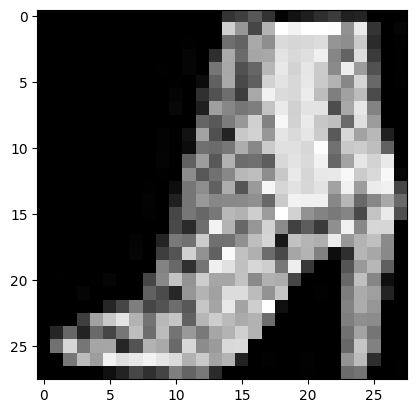

In [74]:
# image图片中有64张图片，我们查看索引为0的图片
imagedemo = image[0]
imagedemolabel = label[0]

imagedemo = imagedemo.reshape((28,28))

plt.imshow(imagedemo, cmap='gray')

labellist = ['T恤','裤子','套衫','裙子','外套','凉鞋','汗衫','运动鞋','包','靴子']
print(f'这张图片对应的标签是 {labellist[imagedemolabel]}')

## 搭建神经网络

让我们搭建一个简单的全连接神经网络，实现Fashion-MNIST数据集的图像分类任务。

首先，设计神经网络的结构，我们这里定义一个4层全连接神经网络：

- **输入层**：由于图片长、宽均为28像素，则输入元素数量为28 * 28 = 784；
- **隐藏层1**：包含256个神经元；
- **隐藏层2**：包含128个神经元；
- **隐藏层3**: 包含64个神经元；
- **输出层**：输出10个结果，对应图片属于10个分类的概率。

In [75]:
class Classifier(nn.Module):
    """
    图像分类器，其结构为4层全连接神经网络。
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        
    def forward(self, x):
        # 将输入张量展平到1维
        x = x.view(x.shape[0], -1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        
        return x

## 训练模型

定义损失函数，并采用适当的优化器，对模型进行训练。

In [76]:
# 对上面定义的Classifier类进行实例化
model = Classifier()

# 定义损失函数为负对数损失函数
criterion = nn.NLLLoss()

# 优化方法为Adam梯度下降方法，学习率为0.003
optimizer = optim.Adam(model.parameters(), lr=0.003)

# 对训练集的全部数据学习15遍，这个数字越大，训练时间越长
epochs = 15

# 将每次训练的训练误差和测试误差存储在这两个列表里，后面绘制误差变化折线图用
train_losses, test_losses = [], []

print('开始训练')
for e in range(epochs):
    running_loss = 0
    
    # 对训练集中的所有图片都过一遍
    for images, labels in trainloader:
        # 将优化器中的求导结果都设为0，否则会在每次反向传播之后叠加之前的梯度
        optimizer.zero_grad()
        
        # 对64张图片进行推断，计算损失函数，反向传播优化权重，将损失求和
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # 每次学完一遍数据集，都进行以下测试操作
    else:
        test_loss = 0
        accuracy = 0
        # 测试的时候不需要开自动求导和反向传播
        with torch.no_grad():
            # 关闭Dropout
            model.eval()
            
            # 对测试集中的所有图片都过一遍
            for images, labels in testloader:
                # 对传入的测试集图片进行正向推断、计算损失，accuracy为测试集一万张图片中模型预测正确率
                log_ps = model(images)
                test_loss += criterion(log_ps, labels)
                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                
                # 等号右边为每一批64张测试图片中预测正确的占比
                accuracy += torch.mean(equals.type(torch.FloatTensor))
        # 恢复Dropout
        model.train()
        # 将训练误差和测试误差存在两个列表里，后面绘制误差变化折线图用
        train_losses.append(running_loss/len(trainloader))
        test_losses.append(test_loss/len(testloader))

        print("训练集学习次数: {}/{}; ".format(e+1, epochs),
              "训练误差: {:.3f}; ".format(running_loss/len(trainloader)),
              "测试误差: {:.3f}; ".format(test_loss/len(testloader)),
              "模型分类准确率: {:.3f}.".format(accuracy/len(testloader)))

开始训练
训练集学习次数: 1/15;  训练误差: 0.518;  测试误差: 0.454;  模型分类准确率: 0.832.
训练集学习次数: 2/15;  训练误差: 0.387;  测试误差: 0.407;  模型分类准确率: 0.852.
训练集学习次数: 3/15;  训练误差: 0.354;  测试误差: 0.399;  模型分类准确率: 0.856.
训练集学习次数: 4/15;  训练误差: 0.334;  测试误差: 0.386;  模型分类准确率: 0.860.
训练集学习次数: 5/15;  训练误差: 0.315;  测试误差: 0.372;  模型分类准确率: 0.869.
训练集学习次数: 6/15;  训练误差: 0.300;  测试误差: 0.360;  模型分类准确率: 0.874.
训练集学习次数: 7/15;  训练误差: 0.292;  测试误差: 0.365;  模型分类准确率: 0.868.
训练集学习次数: 8/15;  训练误差: 0.278;  测试误差: 0.406;  模型分类准确率: 0.859.
训练集学习次数: 9/15;  训练误差: 0.271;  测试误差: 0.356;  模型分类准确率: 0.878.
训练集学习次数: 10/15;  训练误差: 0.264;  测试误差: 0.365;  模型分类准确率: 0.879.
训练集学习次数: 11/15;  训练误差: 0.260;  测试误差: 0.367;  模型分类准确率: 0.873.
训练集学习次数: 12/15;  训练误差: 0.248;  测试误差: 0.382;  模型分类准确率: 0.876.
训练集学习次数: 13/15;  训练误差: 0.244;  测试误差: 0.380;  模型分类准确率: 0.877.
训练集学习次数: 14/15;  训练误差: 0.238;  测试误差: 0.358;  模型分类准确率: 0.882.
训练集学习次数: 15/15;  训练误差: 0.234;  测试误差: 0.377;  模型分类准确率: 0.873.


可视化训练和测试损失。

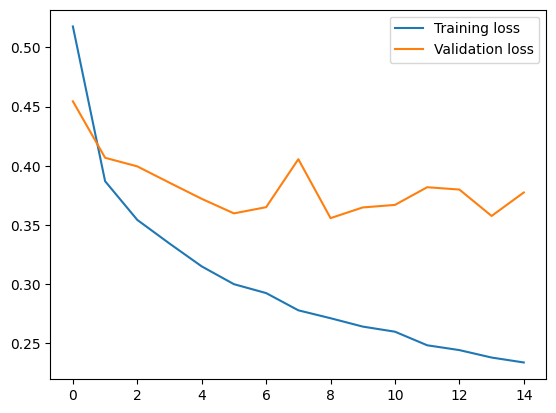

In [77]:
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend()

## 基于模型进行推理

神经网络猜测图片里是 裤子，概率为100.0%
正确标签为 裤子


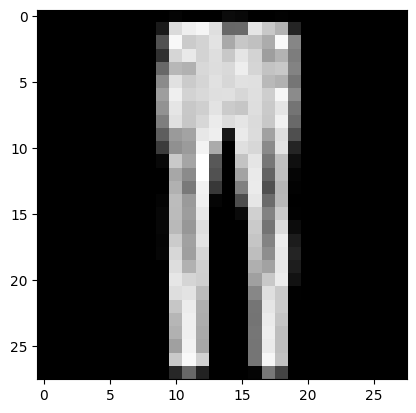

In [82]:
dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[0]
img = img.reshape((28,28)).numpy()
plt.imshow(img, cmap='gray')

# 将测试图片转为一维的列向量
img = torch.from_numpy(img)
img = img.view(1, 784)

# 进行正向推断，预测图片所在的类别
with torch.no_grad():
    output = model.forward(img)
ps = torch.exp(output)

top_p, top_class = ps.topk(1, dim=1)
labellist = ['T恤','裤子','套衫','裙子','外套','凉鞋','汗衫','运动鞋','包','靴子']
prediction = labellist[top_class]
probability = float(top_p)
print(f'神经网络猜测图片里是 {prediction}，概率为{probability*100}%')
print(f'正确标签为 {labellist[labels[0]]}')

反复运行上面的代码，你会发现大多数情况下模型都给出了正确的预测，但也有一定概率推断错误，模型性能还有很大的提升空间。在本课程后续实验中，你将学习更加强大的模型，通过这些模型，能够进一步提升分类准确率。